# Condition-number sensitivity of gauge-transformed broadcast

This self-contained synthetic experiment applies paired non-orthogonal gauges with prescribed condition numbers. At fixed client rank, it compares RBLA and compact SP+ excess error over the dense optimum and separately reports numerical residuals. Condition number controls anisotropic scaling, not prefix quality by itself, so no monotonic RBLA trend is assumed.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

D_OUT, D_IN, R = 128, 96, 16
CLIENT_RANK = 8
KAPPAS = (1.0, 1.5, 2.0, 3.0, 5.0, 7.5, 10.0)
TRIALS = 100
SEED = 42
TARGET_SEED = 20260903
ALPHA = 4.0
TOL = 1e-10
COND_RTOL = 1e-12
EPS = np.finfo(np.float64).eps

cwd = Path.cwd().resolve()
OUTPUT_DIR = cwd if cwd.name == "condition_number_sensitivity" else cwd / "rbla+" / "figures" / "condition_number_sensitivity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
paper_font = "Times New Roman" if "Times New Roman" in available_fonts else "DejaVu Serif"
mpl.rcParams.update({
    "font.family": paper_font, "font.size": 8, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.titlesize": 8, "axes.linewidth": 0.8, "lines.linewidth": 1.45,
    "lines.markersize": 4.2, "grid.color": "0.75", "grid.linestyle": ":",
    "grid.linewidth": 0.5, "grid.alpha": 0.55, "legend.frameon": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
print(f"Output directory: {OUTPUT_DIR}")
print(f"Configuration: {D_OUT} x {D_IN}, R={R}, fixed r={CLIENT_RANK}, trials={TRIALS}")

Output directory: H:\paper-experiment-record\rbla+\figures\condition_number_sensitivity
Configuration: 128 x 96, R=16, fixed r=8, trials=100


In [2]:
def orthonormal_columns(rng, rows, columns):
    q, r = np.linalg.qr(rng.standard_normal((rows, columns)), mode="reduced")
    signs = np.where(np.diag(r) < 0.0, -1.0, 1.0)
    return q * signs[None, :]


def make_structured_factors():
    rng = np.random.default_rng(TARGET_SEED)
    u = orthonormal_columns(rng, D_OUT, R)
    v = orthonormal_columns(rng, D_IN, R)
    spectrum = np.exp(-ALPHA * np.arange(R) / (R - 1))
    spectrum = spectrum / np.linalg.norm(spectrum)
    sqrt_s = np.sqrt(spectrum)
    return u * sqrt_s[None, :], sqrt_s[:, None] * v.T, spectrum


def prescribed_condition_gauge(q_left, q_right, kappa):
    log_scales = np.linspace(-0.5 * np.log(kappa), 0.5 * np.log(kappa), R)
    scales = np.exp(log_scales)
    return (q_left * scales[None, :]) @ q_right.T


def compact_sp_plus(b_global, a_global):
    q_b, r_b = np.linalg.qr(b_global, mode="reduced")
    q_a, r_a = np.linalg.qr(a_global.T, mode="reduced")
    core = r_b @ r_a.T
    u_core, singular_values, vh_core = np.linalg.svd(core, full_matrices=False)
    sqrt_s = np.sqrt(np.maximum(singular_values, 0.0))
    b_plus = (q_b @ u_core) * sqrt_s[None, :]
    a_plus = sqrt_s[:, None] * (vh_core @ q_a.T)
    shapes = [q_b.shape, r_b.shape, q_a.shape, r_a.shape, core.shape,
              u_core.shape, vh_core.shape, b_plus.shape, a_plus.shape]
    dense_shape = (b_global.shape[0], a_global.shape[1])
    if any(shape == dense_shape for shape in shapes):
        raise AssertionError("Compact SP+ created a dense-shaped intermediate")
    return b_plus, a_plus, shapes


def relative_error(reference, approximation):
    return float(np.linalg.norm(reference - approximation, ord="fro") /
                 (np.linalg.norm(reference, ord="fro") + EPS))

In [3]:
b_global, a_global, designed_spectrum = make_structured_factors()
delta_w = b_global @ a_global  # Offline evaluator only.
_, dense_singular_values, _ = np.linalg.svd(delta_w, full_matrices=False)
dense_optimal_error = float(
    np.linalg.norm(dense_singular_values[CLIENT_RANK:]) /
    (np.linalg.norm(dense_singular_values) + EPS)
)

records = []
for trial in range(TRIALS):
    left_rng = np.random.default_rng(SEED + 2 * trial)
    right_rng = np.random.default_rng(SEED + 2 * trial + 1)
    q_left = orthonormal_columns(left_rng, R, R)
    q_right = orthonormal_columns(right_rng, R, R)

    for target_kappa in KAPPAS:
        gauge = prescribed_condition_gauge(q_left, q_right, target_kappa)
        actual_kappa = float(np.linalg.cond(gauge, p=2))
        smallest_singular_value = float(np.linalg.svd(gauge, compute_uv=False)[-1])
        b_gauge = b_global @ gauge
        a_gauge = np.linalg.solve(gauge, a_global)
        full_update_error = relative_error(delta_w, b_gauge @ a_gauge)
        b_plus, a_plus, compact_shapes = compact_sp_plus(b_gauge, a_gauge)
        compact_ok = all(shape != delta_w.shape for shape in compact_shapes)

        rbla_rank_r = b_gauge[:, :CLIENT_RANK] @ a_gauge[:CLIENT_RANK, :]
        sp_rank_r = b_plus[:, :CLIENT_RANK] @ a_plus[:CLIENT_RANK, :]
        rbla_error = relative_error(delta_w, rbla_rank_r)
        sp_error = relative_error(delta_w, sp_rank_r)
        sp_dense_gap = abs(sp_error - dense_optimal_error)
        compact_full_error = relative_error(delta_w, b_plus @ a_plus)

        common = {
            "dataset": "synthetic", "model": "structured_low_rank_update",
            "layer": "aggregate", "checkpoint": "N/A", "seed": SEED,
            "trial": trial, "d_out": D_OUT, "d_in": D_IN,
            "R": R, "r": CLIENT_RANK, "alpha": ALPHA,
            "target_condition_number": target_kappa,
            "actual_condition_number": actual_kappa,
            "condition_relative_error": abs(actual_kappa - target_kappa) / target_kappa,
            "smallest_gauge_singular_value": smallest_singular_value,
            "b_gauge_frobenius_norm": float(np.linalg.norm(b_gauge, ord="fro")),
            "a_gauge_frobenius_norm": float(np.linalg.norm(a_gauge, ord="fro")),
            "full_update_error": full_update_error,
            "dense_optimal_error": dense_optimal_error,
            "sp_plus_dense_error_gap": sp_dense_gap,
            "compact_full_reconstruction_error": compact_full_error,
            "compact_path_no_dense_intermediate": compact_ok,
            "gauge_construction": "Q_left D(kappa) Q_right^T",
        }
        records.append({**common, "method": "RBLA prefix",
                        "broadcast_error": rbla_error,
                        "excess_error": rbla_error - dense_optimal_error})
        records.append({**common, "method": "SP+ (compact QR)",
                        "broadcast_error": sp_error,
                        "excess_error": sp_error - dense_optimal_error})

results = pd.DataFrame.from_records(records)
rbla = results[results["method"] == "RBLA prefix"]
sp_plus = results[results["method"] == "SP+ (compact QR)"]
numeric_columns = ["target_condition_number", "actual_condition_number",
                   "condition_relative_error", "smallest_gauge_singular_value",
                   "b_gauge_frobenius_norm", "a_gauge_frobenius_norm",
                   "full_update_error", "broadcast_error", "dense_optimal_error",
                   "sp_plus_dense_error_gap", "compact_full_reconstruction_error",
                   "excess_error"]
checks = {
    "achieved condition numbers match their targets": bool(results["condition_relative_error"].max() <= COND_RTOL),
    "all gauges are nonsingular": bool(results["smallest_gauge_singular_value"].min() > 0.0),
    "all gauges satisfy the condition-number limit": bool(results["actual_condition_number"].max() <= max(KAPPAS) * (1 + COND_RTOL)),
    "all complete updates are gauge invariant": bool(results["full_update_error"].max() <= TOL),
    "SP+ matches the dense optimum": bool(results["sp_plus_dense_error_gap"].max() <= TOL),
    "compact full-rank reconstruction is accurate": bool(results["compact_full_reconstruction_error"].max() <= TOL),
    "compact SP+ has no dense-shaped intermediate": bool(results["compact_path_no_dense_intermediate"].all()),
    "all numeric values are finite": bool(np.isfinite(results[numeric_columns]).all().all()),
    "RBLA excess is non-negative within tolerance": bool(rbla["excess_error"].min() >= -TOL),
}
all_checks_passed = all(checks.values())
results["numerical_checks_passed"] = all_checks_passed
csv_path = OUTPUT_DIR / "condition_number_sensitivity.csv"
results.to_csv(csv_path, index=False, float_format="%.16e")
check_table = pd.DataFrame({"check": checks.keys(), "passed": checks.values()})
display(check_table)
assert all_checks_passed, check_table.loc[~check_table["passed"], "check"].tolist()
print(f"Saved {len(results):,} rows to {csv_path.name}")

,check,passed
0,achieved condition numbers match their targets,True
1,all gauges are nonsingular,True
2,all gauges satisfy the condition-number limit,True
3,all complete updates are gauge invariant,True
4,SP+ matches the dense optimum,True
5,compact full-rank reconstruction is accurate,True
6,compact SP+ has no dense-shaped intermediate,True
7,all numeric values are finite,True
8,RBLA excess is non-negative within tolerance,True


Saved 1,400 rows to condition_number_sensitivity.csv


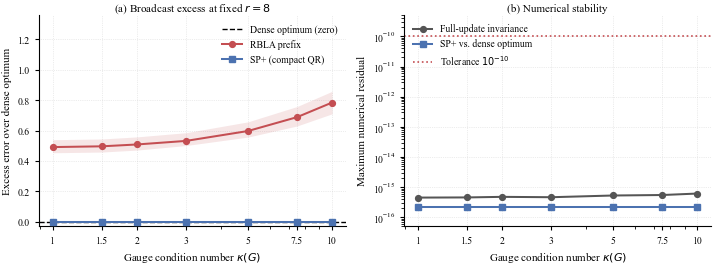

Saved vector figure to condition_number_sensitivity.pdf


In [4]:
method_stats = (
    results.groupby(["target_condition_number", "method"])["excess_error"]
    .agg(median="median", q25=lambda values: values.quantile(0.25),
         q75=lambda values: values.quantile(0.75))
    .reset_index()
)
residual_stats = (
    results.groupby("target_condition_number")
    .agg(max_full_update_error=("full_update_error", "max"),
         max_sp_dense_gap=("sp_plus_dense_error_gap", "max"))
    .reset_index()
)

fig, (ax_error, ax_residual) = plt.subplots(1, 2, figsize=(7.16, 2.70))
method_styles = {
    "RBLA prefix": dict(color="#C44E52", marker="o", label="RBLA prefix"),
    "SP+ (compact QR)": dict(color="#4C72B0", marker="s", label="SP+ (compact QR)"),
}
ax_error.axhline(0.0, color="black", linestyle="--", linewidth=1.0,
                 label="Dense optimum (zero)", zorder=1)
for method, style in method_styles.items():
    group = method_stats[method_stats["method"] == method].sort_values("target_condition_number")
    x = group["target_condition_number"].to_numpy(dtype=float)
    median = group["median"].to_numpy(dtype=float)
    q25 = group["q25"].to_numpy(dtype=float)
    q75 = group["q75"].to_numpy(dtype=float)
    ax_error.fill_between(x, q25, q75, color=style["color"], alpha=0.14, linewidth=0)
    ax_error.plot(x, median, color=style["color"], marker=style["marker"],
                  label=style["label"], zorder=3)

maximum_excess = float(rbla["excess_error"].max())
ax_error.set_xscale("log")
ax_error.set_xticks(KAPPAS)
ax_error.set_xticklabels([f"{kappa:g}" for kappa in KAPPAS])
ax_error.set_ylim(-0.025 * maximum_excess, 1.08 * maximum_excess)
ax_error.set_xlabel(r"Gauge condition number $\kappa(G)$")
ax_error.set_ylabel("Excess error over dense optimum")
ax_error.set_title(r"(a) Broadcast excess at fixed $r=8$", pad=3)
ax_error.legend(loc="upper right", handlelength=2.0)

x = residual_stats["target_condition_number"].to_numpy(dtype=float)
full_residual = residual_stats["max_full_update_error"].to_numpy(dtype=float)
sp_residual = residual_stats["max_sp_dense_gap"].to_numpy(dtype=float)
ax_residual.plot(x, np.maximum(full_residual, EPS), color="#555555", marker="o",
                 label="Full-update invariance")
ax_residual.plot(x, np.maximum(sp_residual, EPS), color="#4C72B0", marker="s",
                 label="SP+ vs. dense optimum")
ax_residual.axhline(TOL, color="#C44E52", linestyle=":", linewidth=1.2,
                    label=r"Tolerance $10^{-10}$")
ax_residual.set_xscale("log")
ax_residual.set_yscale("log")
ax_residual.set_xticks(KAPPAS)
ax_residual.set_xticklabels([f"{kappa:g}" for kappa in KAPPAS])
ax_residual.set_ylim(5e-17, 5e-10)
ax_residual.set_xlabel(r"Gauge condition number $\kappa(G)$")
ax_residual.set_ylabel("Maximum numerical residual")
ax_residual.set_title("(b) Numerical stability", pad=3)
ax_residual.legend(loc="upper left", handlelength=2.0)

for ax in (ax_error, ax_residual):
    ax.grid(True, which="major")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", width=0.8, length=3)
fig.tight_layout(pad=0.3, w_pad=1.0)
pdf_path = OUTPUT_DIR / "condition_number_sensitivity.pdf"
fig.savefig(pdf_path)
plt.show()
print(f"Saved vector figure to {pdf_path.name}")

In [5]:
display(method_stats)
print("Condition-number sensitivity summary")
print(f"  target kappas: {KAPPAS}; trials: {TRIALS}; fixed R={R}, r={CLIENT_RANK}")
print(f"  maximum relative condition-number error: {results['condition_relative_error'].max():.3e}")
print(f"  maximum full-update invariance error: {results['full_update_error'].max():.3e}")
print(f"  maximum SP+ versus dense-optimum error difference: {results['sp_plus_dense_error_gap'].max():.3e}")
print(f"  maximum compact full-rank reconstruction error: {results['compact_full_reconstruction_error'].max():.3e}")
print(f"  all numerical checks passed: {all_checks_passed}")
print("  No monotonic dependence of RBLA excess on condition number is assumed.")
print("  Conclusions are limited to broadcast representation, not aggregation semantics.")

,target_condition_number,method,median,q25,q75
0,1.0,RBLA prefix,4.912162e-01,4.538563e-01,5.398534e-01
1,1.0,SP+ (compact QR),1.387779e-17,1.387779e-17,1.387779e-17
2,1.5,RBLA prefix,4.962318e-01,4.584650e-01,5.445988e-01
3,1.5,SP+ (compact QR),1.387779e-17,1.387779e-17,1.387779e-17
4,2.0,RBLA prefix,5.083445e-01,4.713771e-01,5.582166e-01
5,2.0,SP+ (compact QR),1.387779e-17,1.387779e-17,1.387779e-17
6,3.0,RBLA prefix,5.318564e-01,5.014089e-01,5.858321e-01
7,3.0,SP+ (compact QR),1.387779e-17,1.387779e-17,1.387779e-17
8,5.0,RBLA prefix,5.970153e-01,5.571234e-01,6.573280e-01
9,5.0,SP+ (compact QR),1.387779e-17,1.387779e-17,1.734723e-17


Condition-number sensitivity summary
  target kappas: (1.0, 1.5, 2.0, 3.0, 5.0, 7.5, 10.0); trials: 100; fixed R=16, r=8
  maximum relative condition-number error: 1.658e-15
  maximum full-update invariance error: 6.152e-16
  maximum SP+ versus dense-optimum error difference: 4.163e-17
  maximum compact full-rank reconstruction error: 2.765e-15
  all numerical checks passed: True
  No monotonic dependence of RBLA excess on condition number is assumed.
  Conclusions are limited to broadcast representation, not aggregation semantics.
